#Neural Network Classification in Pytorch
The classification problem is one of the most common ML problem. Simply, the problem is about deciding whether something is one thing or the other.

There are three types of classification problems:
1. Binary Classification
    - There can be one outcome attached to the input (classes).
    - Simply, either this or that.
2. Multiclass Classfication
    - There can only be one label attached to the input.
    - However, the classes to choose from are more than two.
    - Example: dog, cat, or a human.
3. Multilabel Classification
    - There can be more than one label(outcomes) attached to the input.
    - So, multiple labels can be given simultaneously.
    - Example: An article's field might include science, tech, and bio.

##Classification Inputs and Ouputs
Unlike Linear Regression model, the raw inputs for classificatin problems are not generally numerical. Lets say the input is an image, then:

**Image -> Numerical Encoding(input to the model) -> Some ML Algo -> Outputs -> Actual output(lables for human understanding)**

The neural network initially produces logits, which are raw numerical scores. These logits are then converted into probabilities:

- Binary Classification: Uses the Sigmoid activation function.
- Multiclass Classification: Uses the Softmax activation function.
- Multilabel Classification: Uses Sigmoid independently for each class.

The predicted class is obtained by selecting the class with the highest probability (or by applying a threshold in binary and multilabel classification).

###Input and Output shapes
As we know, both the inputs and outputs will be in the form of tensors, and all tensors have shapes. Both the input and output shapes vary according the problem.

For example: For an image classificaton the

    input_shape = [batch_size, color_channels, widht, height]
    batch_size is the no. of images the model will look at at the time.
    It is generally None or 32.  

    output_shape = [batch_size, depends on the no of classes]
    for 3 classes the shape will be [32, 3]


##Architecture of a classification netowrk
```text
  Input layer shape(in_feature)
  ↓
  Hidden layer
  ↓
  Neurons per hidden layer (10-512)
  ↓
  Output layer shape(out_features)
  ↓
  Hidden layer activation
  ↓
  Output activation
```

In [54]:
from sklearn.datasets import make_circles
import torch
from torch import nn
import matplotlib.pyplot as plt
import pandas as pd
import numpy

##1. Creating Data for classification
We will create our own toy dataset for this problem through scikit-learn's make_circles function.

Toy dataset is a simple sample dataset that is small enough to experiment with but also large enough to learn the fundamentals of deep learning.

In [55]:
n_samples = 1000

x, y = make_circles(n_samples, noise= 0.03, random_state=42)
print(f"First 5 x points: {x[:5]}")
print(f"FIrst 5 y points: {y[:5]}")

First 5 x points: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
FIrst 5 y points: [1 1 1 1 0]


In [56]:
#So, there are two x values for each y values
#Let's visualize them with pandas dataframe
circles = pd.DataFrame({"x1" : x[:, 0],
                       "x2": x[:, 1],
                       "Label" : y})

#lets look at the first 10 labels
circles.head(10)

,x1,x2,Label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


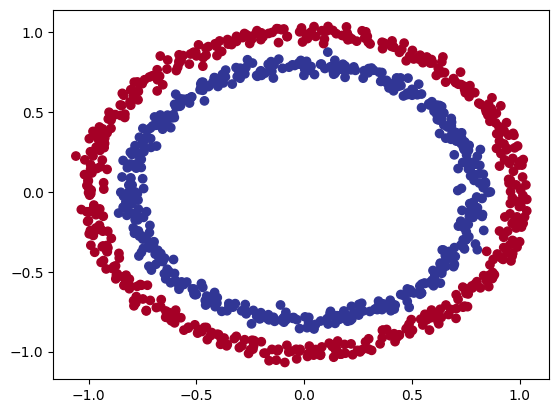

In [57]:
#Also lets plot the points in the scatter plot
# Visualize with a plot
plt.scatter(x=x[:, 0],
            y=x[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);

So, now our problem is to classify the dots into red(0) or blue(1).

###Converting data to tensors and creating **RANDOM** train and test splits
As the data we have created a numpy array, we need to covert them into tensors, because well, pytorch deals in tensors.

To create train and test splits, we will use sikit-learn's random splitter i.e.,
train_test_split() function.

In [58]:
#Converting to tensors and pytorch's defauls float32 dtype
x = torch.from_numpy(x).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

x.dtype, y.dtype

(torch.float32, torch.float32)

In [59]:
#Creating an 80-20 train-test split
from sklearn.model_selection import  train_test_split

#the function has a speciic order we need to follow
x_train, x_test, y_train, y_test = train_test_split(x , y, test_size = 0.2,
                                                    random_state = 42)

len(x_train), len(x_test), len(y_train), len(y_test)

(800, 200, 800, 200)

##2. Building a model
To build a classification model, we will follow similar steps to that of the linear regression model.

1. Set up device agnostic code. (Make this a habit)
2. Create the model. (Remember that we subclass it from nn.Module)
3. Set up loss function and optimizer. Both should be appropriate for the problem.
4. Run the train and test loop.

In [60]:
#Device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [61]:
#Let's construct the model now
class ClassifyV0(nn.Module):
  def __init__(self):
    super().__init__()

    #Create hidden layers that can handle the input's and output's shape
    self.layer1 = nn.Linear(in_features = 2, out_features= 8)
    self.layer2 = nn.Linear(in_features= 8, out_features = 1)

  def forward(self, x: torch.tensor) -> torch.tensor:
    return self.layer2(self.layer1(x)) # x -> layer1 -> layer2 -> output

model0 = ClassifyV0().to(device)

Here, layer1 and layer 2 are the hidden layers of the neural networks.

Layer1 takes in two features i.e., x1 and x2 and then transforms them to 8 learned features. layer2 will then take those 8 features to give use the output.

The features taken by layer2 should match the features given by the layer1, as they are connected.

The out_features are generally of mutiples of 8 for computational reasons, but we can choose whatever we want.

Increasing the number of hidden units (neurons) or adding more hidden layers increases the capacity of the model, allowing it to learn more complex patterns. However, if the model becomes too large, it may overfit the training data.

###torch.nn.sequential()
We can replicate the model above with the nn.sequential module without subclassing the nn.Module.

Code:

`model0 = nn.Sequential(
  nn.Linear(in_features = 2, out_features = 8),
  nn.Linear(in_features = 8, out_features = 1)).to(device)`

nn.Sequential will forward pass the data in the order the layers are listed. If the model's forward pass cannot be expressed as a simple sequence of layers, nn.Sequential is not suitable. In such cases, subclass nn.Module and implement a custom forward() method.

In [62]:
#Set up a loss function and an optimizer
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params= model0.parameters(), lr = 0.01)

In [63]:
#lets also create an evaluation metric with accuracy
#it would be stupid(for me) to define what accuracy means
def accuracy(y_true, y_pred):
  #torch.eq returns boolean tensor
  correct_count = torch.eq(y_true, y_pred).sum().item()

  accuracy = (correct_count / len(y_pred)) * 100

  return accuracy

##3. Training the model
Revising the training steps of a model:
1. Do the forward pass.
2. Calculate the loss.
3. Optimizer zero grad
4. Loss Backward (Backpropagation)
5. Optimizer step (Gradient descent)

Generally in the classification problems, the output of the final layer of the NN is a logit. Logit is the raw output of the classification NN.

We need to convert those logits to prediction probabilites by passing it into a activation function.
- For Binary classification, we use the sigmoid() function.
- For Multiclass, we use the softmax() function.
- For Mulitlabel, we use the sigmoid() function independently in each class.

Then, we also either round() or argmax() the probabilites to get into the format we want i.e., either 0 or 1 for binary classification.

This is where the advantage of the BCEWithLogitLoss() comes in. When training, we dont need to use the activation function if we use this loss function as it comes built in.

However, when predicting the values or evaluating the model, we still need to use the activation function to obtain the prediction probabilites.

Lets try out this without training i.e., with some random data.

In [64]:
model0.eval()

with torch.inference_mode():
  #Calculate logits
  y_logits_random = model0(x_test.to(device))

  #calculate the prediction probailites
  y_preds_probab_random = torch.sigmoid(y_logits_random)

  #round the prediction probabilites
  y_preds = torch.round(y_preds_probab_random)

#lets look at the first five values
y_preds[:5].T


tensor([[1., 0., 1., 0., 1.]])

This prediction is veryyyyyy random because we haven't train the model yet.

In [65]:
#Let's create the training and testing loop
torch.manual_seed(42)

#epochs
epochs = 100

#device agnostic data
x_train, x_test = x_train.to(device), x_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

#start loop
for epoch in range(epochs):
  model0.train()

  #forward pass
  y_logits = model0(x_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  #calculate loss and accuracy
  loss = loss_fn(y_logits, y_train)
  train_accuracy = accuracy(y_true= y_train, y_pred= y_pred)

  #optimizer zero grad
  optimizer.zero_grad()

  #Loss backward
  loss.backward()

  #optimizer step
  optimizer.step()


  ###Testing loop
  model0.eval()

  with torch.inference_mode():
    test_logits = model0(x_test).squeeze()

    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_accuracy = accuracy(y_true= y_test, y_pred = test_pred)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} || Train_loss: {loss:.3f} Train_accuracy: {train_accuracy} || Test_loss {test_loss:.3f} Test_accuracy: {test_accuracy} ")

Epoch: 0 || Train_loss: 0.706 Train_accuracy: 50.375 || Test_loss 0.695 Test_accuracy: 51.0 
Epoch: 10 || Train_loss: 0.705 Train_accuracy: 50.5 || Test_loss 0.695 Test_accuracy: 51.5 
Epoch: 20 || Train_loss: 0.705 Train_accuracy: 49.875 || Test_loss 0.695 Test_accuracy: 52.0 
Epoch: 30 || Train_loss: 0.704 Train_accuracy: 49.875 || Test_loss 0.694 Test_accuracy: 52.0 
Epoch: 40 || Train_loss: 0.704 Train_accuracy: 49.875 || Test_loss 0.694 Test_accuracy: 52.0 
Epoch: 50 || Train_loss: 0.703 Train_accuracy: 50.24999999999999 || Test_loss 0.694 Test_accuracy: 51.0 
Epoch: 60 || Train_loss: 0.703 Train_accuracy: 50.375 || Test_loss 0.694 Test_accuracy: 50.5 
Epoch: 70 || Train_loss: 0.702 Train_accuracy: 50.0 || Test_loss 0.694 Test_accuracy: 51.0 
Epoch: 80 || Train_loss: 0.702 Train_accuracy: 50.24999999999999 || Test_loss 0.693 Test_accuracy: 50.5 
Epoch: 90 || Train_loss: 0.701 Train_accuracy: 50.24999999999999 || Test_loss 0.693 Test_accuracy: 51.0 


We can see that the model is not really learning. The train loss and train accuracy both hover around the same values for several epochs.

If we look at the decision boundary of the train and test loss of our model, we will see that it is a straight line. So, it essentially cuts the points in half which is equivalent to randomly guessing it every time(which causes 50% accuracy)

##4. Improving the model
There are many ways we can improve our pytorch model:
1. Adding more layers
    - Adding more hidden layers increases the model's capacity to learn complex patterns.
    - This is known as making the NN deeper.
2. Adding more hidden units
    - Similary to adding more layers, adding more hidded units also provides more opportunity to learn.
    - This is known as making the NN wider.
3. Fitting for longer
    - Running the training loop for more epochs might improve the model.
    - But training for longer might also cause overfitting.  
4. Changing or adding the activation function
    - Hidden layers almost always use nonlinear activation functions (such as ReLU, Tanh, or Sigmoid). Without them, stacking multiple linear layers is equivalent to a single linear layer.
    - This might solve our problem with the model.
5. Changing the learning rate
    - This is not as relevant to model's inaccuracies, but too small might make the learning slower while too large of the rate might drastically change the learned features skipping over the value we desire.
    - So, it might overshoot the optimum or fail to converge if lr is too large.
6. Changing the loss function
    - There are different loss functions for different problems in ML.
    - We use binary cross entropy function for Binary classification and Cross entropy function for Multiclass Classification.


**So, what about our model?**

One of the main reasons our model performs poorly is that it lacks a nonlinear activation function. Without a nonlinear activation function, stacking multiple linear layers is mathematically equivalent to using a single linear layer. As a result, the model can only learn linear decision boundaries.

Our CircleV0 model is therefore not expressive enough to learn the nonlinear relationship present in the dataset. This results in underfitting, where the neural network is unable to capture the underlying patterns in the training data.

##5. Non-Linearlity
So, the missing piece of our model is non-linearity. Without a non-linear activation function, what our model is trying to do is draw some linear patterns from non-linear data. So, if the model only contains non-linear layers, it cannot learn the non-linear relationships between the data(if it is non-linear).

Nonlinear activation functions allow a neural network to learn complex, nonlinear relationships by transforming the outputs of linear layers. To think of why non-linear patters matter, think of how many of patters could you determine on yourself if you were given linear functions and non-linear functions.

Pytorch gives us many non-linear activation functions. **nn.ReLU** is the most commonly used activation function because it is simple, computationally efficient, and performs well in many deep learning tasks.

This is why most of the Neural Networks contain non-linear activation functions because MOST if not ALL of the real-world applications contain non-linear data.



In [69]:
#Construction second version of the model with non-linearity
#Lets use nn.Sequential for easiness as we want sequential forward pass anyways
model1 = nn.Sequential(
    nn.Linear(in_features= 2, out_features = 16),
    nn.ReLU(),
    nn.Linear(in_features= 16, out_features = 16),
    nn.ReLU(),
    nn.Linear(in_features = 16, out_features = 1)
)
model1

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)

The standard order of linear layers and non-linear activation function is to out non-linear activation functions between the linear layers.

Why this order?

A linear layer computes a weighted sum of its inputs:

    y=Wx+b

This transforms the data into a new representation.

The activation function is then applied to introduce nonlinearity:

    y=ReLU(Wx+b)

This combination allows the network to learn complex relationships.



In [73]:
#lets train our new model now
torch.manual_seed(42)
#setup optimizer
optimizer1 = torch.optim.SGD(params= model1.parameters(), lr = 0.1)

#new epochs
epochs_new = 1000
#training loop
for epoch in range(epochs_new):
  model1.train()

  #forward pass
  train_logits_new = model1(x_train).squeeze()
  train_pred_new = torch.round(torch.sigmoid(train_logits_new))

  #loss and accuracy
  loss_new = loss_fn(train_logits_new, y_train)
  accuracy_new = accuracy(y_train, train_pred_new)

  #optimizer zero grad
  optimizer1.zero_grad()

  #loss backward
  loss_new.backward()

  #optimizer step
  optimizer1.step()

  ##Testing loop
  model1.eval()
  with torch.inference_mode():
    #forward pass
    test_logits_new = model1(x_test).squeeze()
    test_pred_new = torch.round(torch.sigmoid(test_logits_new))

    #loss and accuracy
    test_loss_new = loss_fn(test_logits_new, y_test)
    test_accuracy_new = accuracy(y_test, test_pred_new)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} || Train_loss: {loss_new:.3f} Train_accuracy: {accuracy_new:.2f} || Test_loss {test_loss_new:.3f} Test_accuracy: {test_accuracy_new:.2f} ")

Epoch: 0 || Train_loss: 0.684 Train_accuracy: 63.50 || Test_loss 0.687 Test_accuracy: 59.50 
Epoch: 100 || Train_loss: 0.677 Train_accuracy: 65.62 || Test_loss 0.683 Test_accuracy: 61.00 
Epoch: 200 || Train_loss: 0.666 Train_accuracy: 71.50 || Test_loss 0.675 Test_accuracy: 64.00 
Epoch: 300 || Train_loss: 0.650 Train_accuracy: 77.38 || Test_loss 0.662 Test_accuracy: 72.00 
Epoch: 400 || Train_loss: 0.623 Train_accuracy: 81.62 || Test_loss 0.639 Test_accuracy: 78.00 
Epoch: 500 || Train_loss: 0.573 Train_accuracy: 87.62 || Test_loss 0.595 Test_accuracy: 84.00 
Epoch: 600 || Train_loss: 0.485 Train_accuracy: 94.25 || Test_loss 0.518 Test_accuracy: 93.50 
Epoch: 700 || Train_loss: 0.361 Train_accuracy: 97.25 || Test_loss 0.407 Test_accuracy: 94.50 
Epoch: 800 || Train_loss: 0.230 Train_accuracy: 99.50 || Test_loss 0.279 Test_accuracy: 98.00 
Epoch: 900 || Train_loss: 0.137 Train_accuracy: 99.88 || Test_loss 0.179 Test_accuracy: 99.50 


After training our new model with non-linearity for around 5k times we can see that the accuracy increases massively.

Lets see the decision boundary of the model.

A decision boundary is the boundary (or dividing line/surface) that a machine learning model learns to separate different classes in the input space.

We can see how model1's decison boundary is non-linear. This is how the ReLU() makes the NN work.

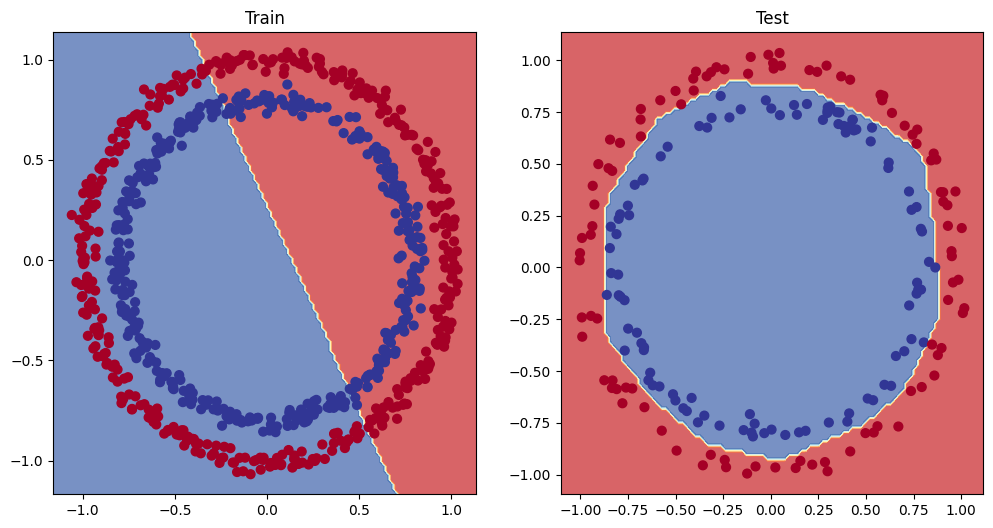

In [76]:
from helper_functions import plot_decision_boundary

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model0, x_train, y_train) # model0 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model1, x_test, y_test) # model1= has non-linearity